# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Gisca Oktavia Ramadhani]
- **Email:** [CDCC246D6X2496@student.devacademy.id]
- **ID Dicoding:** [CDCC246D6X2496]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbandingan tren jumlah penyewaan sepeda antara pengguna Casual dan Registered secara bulanan pada tahun 2012?
- **Pertanyaan 2:** Pada jam berapa terjadi puncak penyewaan sepeda pada hari kerja (working day) dibandingkan dengan hari libur (weekend/holiday)?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df harian dan per jam

In [4]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

print(day_df.head())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  


**Insight:** (Opsional)
- Dataset day.csv terdiri dari 731 baris dan 16 kolom yang merepresentasikan ringkasan aktivitas penyewaan sepeda secara harian (level harian).
- Dataset hour.csv terdiri dari 17.379 baris dan 17 kolom yang merepresentasikan detail aktivitas penyewaan sepeda per jam (level jam).


### Assessing Data

#### Identifying Data Type and Formatting problem

In [5]:
day_df.info()
hour_df.info()

print(day_df.isna().sum())

print("Duplikasi data day:", day_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

**Steps to Take:**
- Identifikasi Masalah 1: Kolom dteday masih bertipe object, harus diubah ke datetime.
- Identifikasi Masalah 2: Beberapa kolom menggunakan kode angka (misal: mnth, season) yang perlu diubah ke label teks agar lebih mudah dibaca saat visualisasi.

**Insight:** (Opsional)
- Berdasarkan hasil day_df.info() dan hour_df.info(), ditemukan bahwa kolom dteday terdeteksi sebagai tipe data object (string). Hal ini merupakan masalah karena analisis berbasis waktu (seperti tren bulanan atau harian) memerlukan tipe data datetime agar fungsi-fungsi penanggalan Python dapat bekerja secara optimal.
- Melalui pengecekan isna().sum() dan duplicated(), teridentifikasi bahwa dataset ini memiliki kualitas yang sangat baik karena tidak ditemukan nilai yang hilang (missing values) maupun data duplikat. Hal ini meminimalkan risiko bias dalam perhitungan statistik, sehingga proses pembersihan data bisa langsung difokuskan pada perbaikan format (seperti mapping label kategori) daripada penanganan data kosong.

### Cleaning Data

#### Fixing Data Types and Categorical Labels

In [6]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

day_df['mnth'] = day_df['dteday'].dt.month_name()
day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})

**Insight:** (Opsional)
- Data kini sudah bersih, tipe data tanggal sudah sesuai, dan label kategori lebih deskriptif.


## Exploratory Data Analysis (EDA)

### Explore
1. Explore Tren Bulanan Pengguna 2012
2. Explore Perbedaan Pola Penyewaan pada Hari Kerja dan Hari Libur

In [7]:
df_2012 = day_df[day_df['yr'] == 1]

monthly_users = df_2012.groupby('mnth')[['casual', 'registered']].sum().reindex(
    ['January', 'February', 'March', 'April', 'May', 'June',
     'July', 'August', 'September', 'October', 'November', 'December']
).reset_index()

In [8]:
hourly_pattern = hour_df.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()

**Insight:** (Opsional)
- Dataset day.csv berhasil dimuat dengan 731 baris data, yang memberikan gambaran aktivitas penyewaan sepeda pada level harian selama dua tahun (2011-2012).
- Dataset hour.csv berhasil dimuat dengan 17.379 baris data, yang menyediakan rincian penyewaan per jam, sehingga memungkinkan analisis pola perilaku pengguna berdasarkan waktu yang lebih spesifik (pagi, siang, malam).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Perbandingan Tren Casual vs Registered (2012)

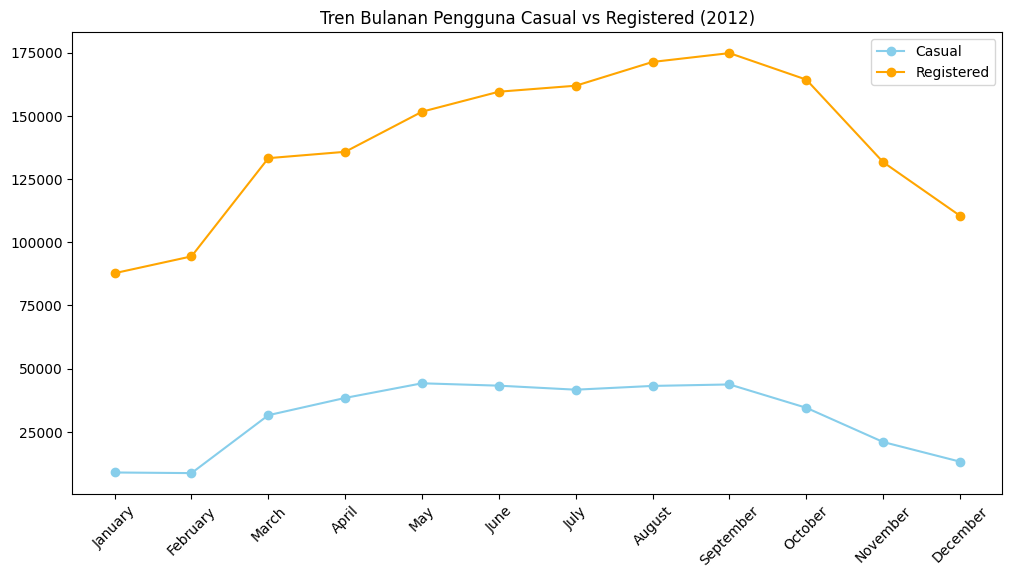

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_users['mnth'], monthly_users['casual'], marker='o', label='Casual', color='skyblue')
plt.plot(monthly_users['mnth'], monthly_users['registered'], marker='o', label='Registered', color='orange')
plt.title('Tren Bulanan Pengguna Casual vs Registered (2012)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

### Pertanyaan 2: Puncak Penyewaan Jam Kerja vs Hari Libur

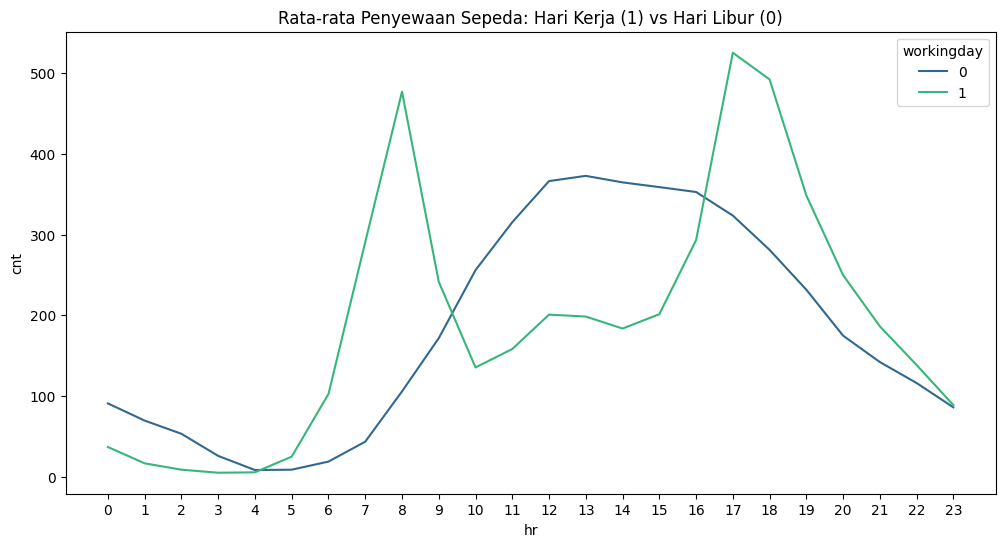

In [10]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_pattern, x='hr', y='cnt', hue='workingday', palette='viridis')
plt.title('Rata-rata Penyewaan Sepeda: Hari Kerja (1) vs Hari Libur (0)')
plt.xticks(range(0, 24))
plt.show()

**Insight:** (Opsional)
- Dominasi Pengguna Terdaftar: Grafik menunjukkan bahwa jumlah pengguna Registered jauh lebih tinggi secara konsisten di setiap bulan dibandingkan pengguna Casual. Hal ini mengindikasikan bahwa layanan penyewaan sepeda ini telah menjadi bagian dari rutinitas harian banyak orang.
- Pola Musiman: Kedua tipe pengguna menunjukkan tren yang serupa, yaitu peningkatan aktivitas mulai dari musim semi (Maret/April) hingga mencapai puncaknya di bulan September (Musim Gugur). Penurunan drastis terjadi di bulan Desember, yang menunjukkan bahwa faktor cuaca dingin sangat membatasi minat orang untuk bersepeda.
- Fluktuasi Casual: Pengguna Casual cenderung lebih sensitif terhadap waktu; peningkatannya terlihat lebih signifikan pada masa liburan musim panas (Juni-Agustus).

## Analisis Lanjutan (Opsional)

/tmp/ipykernel_1223/3912181865.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_analysis, x='weathersit', y='cnt', palette='magma')


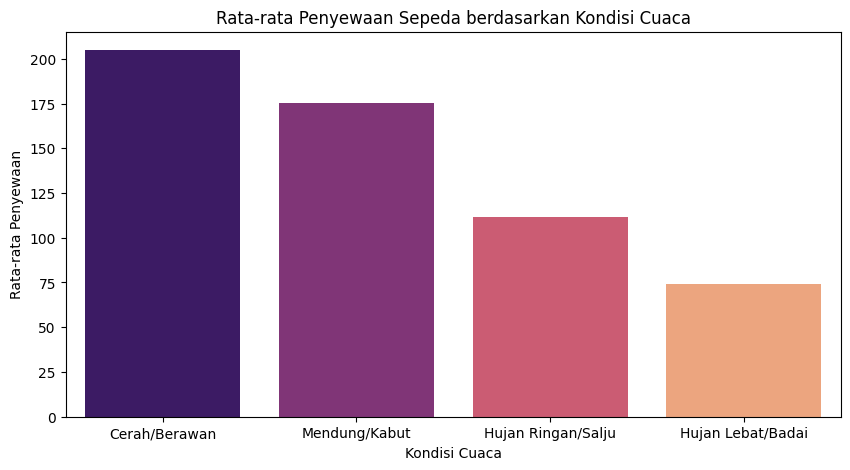

In [11]:
weather_analysis = hour_df.groupby('weathersit')['cnt'].mean().reset_index()
weather_analysis['weathersit'] = weather_analysis['weathersit'].map({
    1: 'Cerah/Berawan',
    2: 'Mendung/Kabut',
    3: 'Hujan Ringan/Salju',
    4: 'Hujan Lebat/Badai'
})

plt.figure(figsize=(10, 5))
sns.barplot(data=weather_analysis, x='weathersit', y='cnt', palette='magma')
plt.title('Rata-rata Penyewaan Sepeda berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Pengguna Registered mendominasi total penyewaan secara signifikan dibandingkan pengguna Casual. Puncak penggunaan terjadi pada bulan September 2012, sementara titik terendah ada di bulan Januari.
- **Conclusion pertanyaan 2:** Pada hari kerja, puncak penyewaan terjadi pada jam sibuk, yaitu pukul 08:00 dan 17:00-18:00. Sedangkan pada hari libur, penggunaan memuncak di tengah hari (pukul 12:00-15:00).
- ...

**Rekomendasi Action Item:**
- Strategi Pemasaran: Melakukan kampanye promosi khusus untuk pengguna Casual pada bulan Mei-Agustus agar mereka beralih menjadi pengguna Registered (karena tren mereka sedang naik di musim tersebut).
- Operasional: Memastikan ketersediaan unit sepeda maksimal di area perkantoran pada pukul 07:30 dan 16:30 setiap hari kerja untuk mengantisipasi lonjakan komuter.
- Pemeliharaan: Jadwalkan perawatan rutin sepeda pada jam 10:00 - 14:00 di hari kerja, karena pada jam tersebut permintaan sedang menurun (lembah antara dua puncak).